##Project: Content Monetization Modeling

##Objective:
Predict YouTube ad revenue using engagement metrics such as views,
likes, comments, and engagement rate.

##Workflow:
1. Data Cleaning and EDA
2. Feature Engineering
3. Model Building
4. Model Evaluation
5. Streamlit App Deployment

##Data Cleaning

In [1]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#Loading the data

df_raw=pd.read_csv('/content/youtube_ad_revenue_dataset (1) (1).csv')

In [3]:
df_raw.shape

#(122400, 12)

(122400, 12)

In [4]:
df_raw.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [5]:
df_raw.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd'],
      dtype='object')

In [6]:
df_raw.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [7]:
df_raw.describe(include='object')

,video_id,date,category,device,country
count,122400,122400,122400,122400,122400
unique,5000,365,6,4,6
top,vid_3033,2025-04-03 10:50:40.993199,Education,TV,CA
freq,47,382,20514,30646,20603


In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


##Checking if any Data Inconsistent Formats in Ctaegorical Columns

In [9]:
Cat= df_raw.select_dtypes(include='object')
Cat.columns

Index(['video_id', 'date', 'category', 'device', 'country'], dtype='object')

In [10]:
Cat_data=Cat.drop(['video_id','date'],axis=1)
Cat_data.columns

Index(['category', 'device', 'country'], dtype='object')

In [11]:
for col in Cat_data.columns:
  print(df_raw[col].value_counts())
  print(df_raw[col].unique())

category
Education        20514
Music            20475
Tech             20444
Entertainment    20411
Gaming           20359
Lifestyle        20197
Name: count, dtype: int64
['Entertainment' 'Gaming' 'Education' 'Music' 'Tech' 'Lifestyle']
device
TV         30646
Mobile     30598
Tablet     30579
Desktop    30577
Name: count, dtype: int64
['TV' 'Tablet' 'Mobile' 'Desktop']
country
CA    20603
DE    20582
IN    20564
AU    20313
UK    20269
US    20069
Name: count, dtype: int64
['IN' 'CA' 'UK' 'US' 'DE' 'AU']


##Checking for Duplicates

In [12]:
df_raw.duplicated().sum()

np.int64(2400)

In [13]:
df_raw.drop(columns=['video_id']).duplicated().sum()

np.int64(2400)

In [14]:
#Dropping Duplicates

df_raw=df_raw.drop_duplicates()

In [15]:
df_raw.duplicated().sum()

np.int64(0)

In [16]:
df_raw.shape

(120000, 12)

##Handling Null Values

In [17]:
df_raw.isna().sum()

,0
video_id,0
date,0
views,0
likes,6000
comments,6000
watch_time_minutes,6000
video_length_minutes,0
subscribers,0
category,0
device,0


##Imputing the Null Values in 'comments'

In [18]:
df_raw['comments'].isna().mean()*100

np.float64(5.0)

<Axes: ylabel='Frequency'>

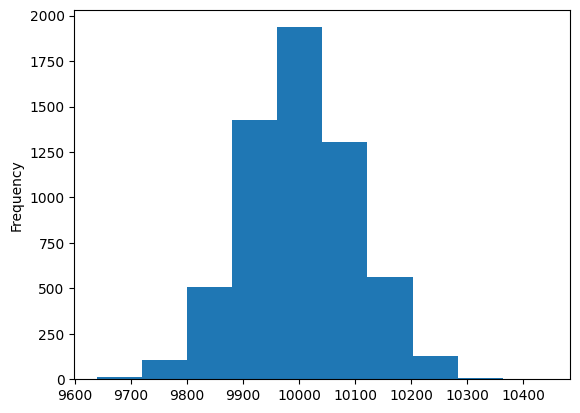

In [19]:
df_raw[df_raw['comments'].isna()]['views'].plot(kind='hist')



1.   Missingness is NOT random — it is happening in a specific range of views
2.   The distribution of views for missing comment entries was concentrated within a narrow range, indicating that missingness was not highly variable. This supports the use of a stable ratio-based imputation using median comment_rate



In [20]:
#Lets Create a Column 'comment_rate'

#comment_rate = comments/views

df_raw['comment_rate'] = df_raw['comments']/df_raw['views']   #As 'comments' have null values, there will create null values in 'comment_rate' too, but we shall handle it later

df_raw['comment_rate'].describe()

,comment_rate
count,114000.000000
mean,0.027436
std,0.012972
min,0.004911
25%,0.016231
50%,0.027368
75%,0.038668
max,0.049990


Instead of relying on general statistical imputation, I used domain-driven feature engineering by deriving comment_rate. As this feature was stable and representative, its median was used to impute missing values in comments.

In [21]:
median_comment_rate = df_raw['comment_rate'].median()
median_comment_rate

0.027367683925724196

In [22]:
df_raw['comments']=df_raw['comments'].fillna(median_comment_rate)

In [23]:
df_raw['comments'].isna().sum()

np.int64(0)

In [24]:
df_raw['comment_rate'] = df_raw['comments']/df_raw['views']   #Will solve the null values issues in 'comment_rate'

In [25]:
df_raw['comment_rate'].isna().sum()

np.int64(0)

##Imputing Null Values in 'likes' Column

In [26]:
#Percentage of Null Values in 'likes'

df_raw['likes'].isna().mean()*100

np.float64(5.0)

In [27]:
df_raw['likes'].describe()

,likes
count,114000.000000
mean,1099.585044
std,519.526733
min,195.000000
25%,650.000000
50%,1102.000000
75%,1547.250000
max,2061.000000


<Axes: >

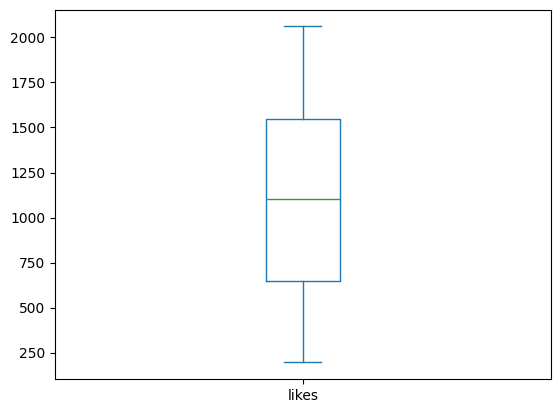

In [28]:
df_raw['likes'].plot(kind='box')

<Axes: ylabel='Frequency'>

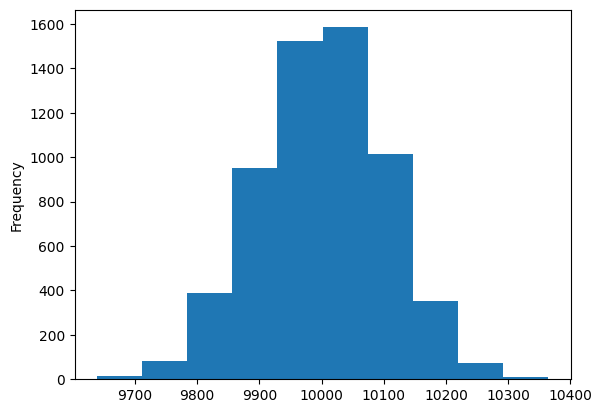

In [29]:
df_raw[df_raw['likes'].isna()]['views'].plot(kind='hist')



1.   Missing values are not random across all data.They are concentrated in a specific, stable region
2.   When missing data lies in a stable region, simple ratio-based imputation becomes highly reliable.



In [30]:
#Creating a Feature 'engagement_rate' where engagement_rate=(likes+comments)/views

df_raw['engagement_rate']= (df_raw['likes']+df_raw['comments'])/df_raw['views']
df_raw['engagement_rate'].describe()

,engagement_rate
count,114000.000000
mean,0.136019
std,0.053730
min,0.019949
25%,0.091234
50%,0.135970
75%,0.180908
max,0.249554


In [31]:
#Now lets impute null values in 'likes'

median_engagement = df_raw['engagement_rate'].median()
median_engagement

0.13597009542075794

In [32]:
mask=df_raw['likes'].isna()

df_raw.loc[mask,'likes']= (median_engagement * df_raw.loc[mask,'views']) - df_raw.loc[mask,'comments']

In [33]:
df_raw['likes'].isna().sum()

np.int64(0)

In [34]:
df_raw['engagement_rate']= (df_raw['likes']+df_raw['comments'])/df_raw['views'] #Recompute this

In [35]:
df_raw['engagement_rate'].isna().sum()

np.int64(0)

##Imputing Null Values in watch_time_minutes

In [36]:
#Percentage of Null values in 'watch_time_minutes'

df_raw['watch_time_minutes'].isna().mean()*100

np.float64(5.0)

In [37]:
df_raw['watch_time_minutes'].describe()

,watch_time_minutes
count,114000.000000
mean,37540.749921
std,12987.818758
min,14659.105562
25%,26364.159667
50%,37522.221205
75%,48782.739997
max,61557.670089


<Axes: ylabel='Frequency'>

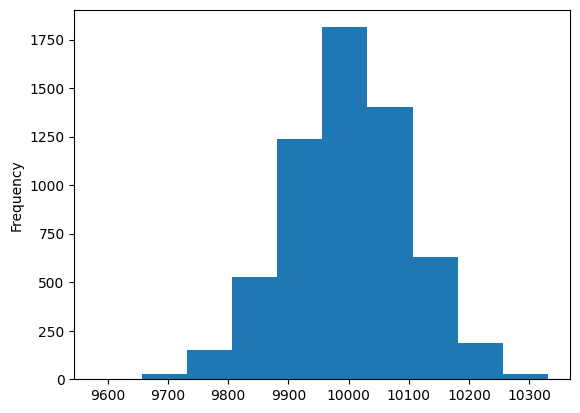

In [38]:
df_raw[df_raw['watch_time_minutes'].isna()]['views'].plot(kind='hist')


*   A feature watch_time_per_view was derived to represent average
viewing duration per view
*   Since the distribution was stable (mean ≈ median), the median value was used to impute missing watch_time_minutes by scaling with views, thereby preserving the relationship between engagement and watch behavior



In [39]:
#KNN Imputer

#from sklearn.impute import KNNImputer

#imputer = KNNImputer(n_neighbors=5)

#cols = ['views', 'likes', 'comments', 'watch_time_minutes']

#df_raw[cols] = imputer.fit_transform(df_raw[cols])

In [40]:
#Now lets create a feature called 'watch_time_per_view' which is watch_time_per_view = watch_time_minutes/views

df_raw['watch_time_per_view'] = df_raw['watch_time_minutes']/df_raw['views']

df_raw['watch_time_per_view'].describe()

,watch_time_per_view
count,114000.000000
mean,3.754158
std,1.298259
min,1.500239
25%,2.636998
50%,3.751789
75%,4.879737
max,5.999977


In [41]:
#Now lets impute the missong values in 'watch_time_minutes'

median_wtpv = df_raw['watch_time_per_view'].median()
median_wtpv

3.7517891665761

In [42]:
mask = df_raw['watch_time_minutes'].isna()

df_raw.loc[mask,'watch_time_minutes']= median_wtpv * df_raw.loc[mask,'views']

In [43]:
df_raw['watch_time_minutes'].isna().sum()

np.int64(0)

In [44]:
df_raw['watch_time_per_view'] = df_raw['watch_time_minutes']/df_raw['views']  #Recomputing this

In [45]:
df_raw['watch_time_per_view'].isna().sum()


np.int64(0)

In [46]:
df_raw.isna().sum()

,0
video_id,0
date,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0


##Data Types Conversion
Ensuring all columns have appropriate data types for analysis

In [47]:
df_raw.dtypes

,0
video_id,object
date,object
views,int64
likes,float64
comments,float64
watch_time_minutes,float64
video_length_minutes,float64
subscribers,int64
category,object
device,object


In [48]:
df_raw.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,comment_rate,engagement_rate,watch_time_per_view
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.032206,0.155093,2.666789
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.034541,0.098632,1.518393
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.018520,0.214519,5.678187
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.024118,0.142814,3.122834
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.048235,0.236121,1.584151


In [49]:
#Changing ['date'] Datatype from 'object' to 'datetime'

df_raw['date']=pd.to_datetime(df_raw['date'],errors='coerce')

In [50]:
#Changing ['likes','comments'] Data type from 'float64' to 'int64'

df_raw['likes']= df_raw['likes'].astype('int64')
df_raw['comments']=df_raw['comments'].astype('int64')

In [51]:
df_raw.dtypes

,0
video_id,object
date,datetime64[ns]
views,int64
likes,int64
comments,int64
watch_time_minutes,float64
video_length_minutes,float64
subscribers,int64
category,object
device,object


##Dropping unwanted columns for Model Building

In [52]:
#Dropping unwanted columns for Model Building

df_raw=df_raw.drop(['video_id','date'],axis=1)

In [53]:
df_raw.shape

(120000, 13)

In [54]:
df_raw.columns

Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'comment_rate', 'engagement_rate',
       'watch_time_per_view'],
      dtype='object')

##Data Cleaning Summary

The original dataset contained 122,400 records.

*   2,400 duplicate rows were identified and removed.
*   The final cleaned dataset contains 120,000 unique records and 13 features.
*   Missing values were handled using Feature Based imputation.
*   A new feature engagement_rate,comment_rate,watch_time_per_view was engineered to capture user interaction.

##Saving the Cleaned Dataset as a New CSV File

In [55]:

df_raw.to_csv('youtube_df_cleaned.csv',index=False)

In [56]:
df_cleaned=pd.read_csv('/content/youtube_df_cleaned.csv')

In [57]:
df_cleaned.shape

(120000, 13)

In [58]:
df_cleaned.isna().sum()

,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0
country,0
ad_revenue_usd,0


In [59]:
df_cleaned.duplicated().sum()

np.int64(0)

In [60]:
df_cleaned.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,comment_rate,engagement_rate,watch_time_per_view
0,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.032206,0.155093,2.666789
1,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.034541,0.098632,1.518393
2,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.018520,0.214519,5.678187
3,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.024118,0.142814,3.122834
4,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.048235,0.236121,1.584151


##Focused univariate and bivariate analysis was performed to understand feature distributions and relationships with the target variable. Key insights from correlation and scatter plots guided feature selection for model building.

##Univariate Analysis(Distribution)

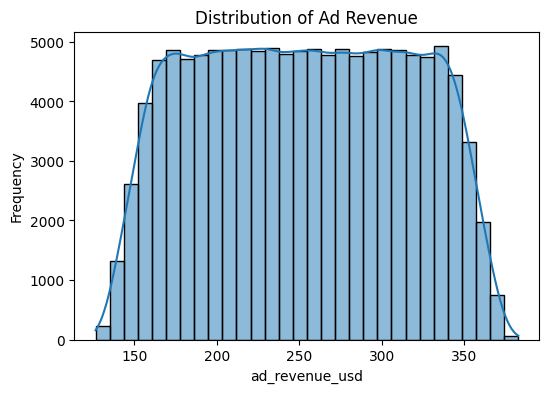

In [61]:
# 1) Histogram of Target Column ---> 'ad_revenue_usd'

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['ad_revenue_usd'], bins=30, kde=True)
plt.title('Distribution of Ad Revenue')
plt.xlabel('ad_revenue_usd')
plt.ylabel('Frequency')
plt.show()

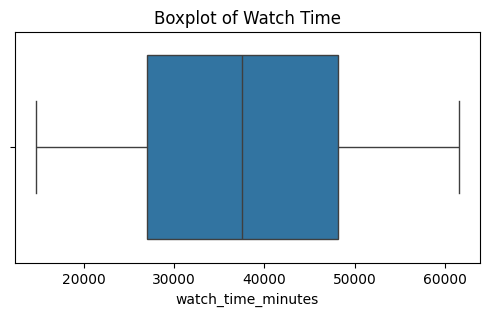

In [62]:
# 2) Boxplot (for outliers)

plt.figure(figsize=(6,3))
sns.boxplot(x=df_cleaned['watch_time_minutes'])
plt.title('Boxplot of Watch Time')
plt.show()

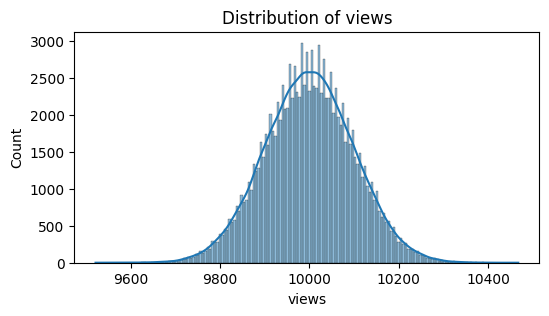

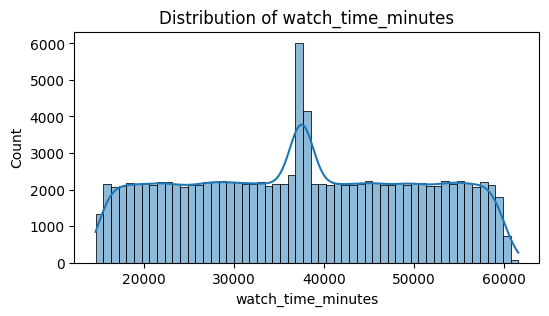

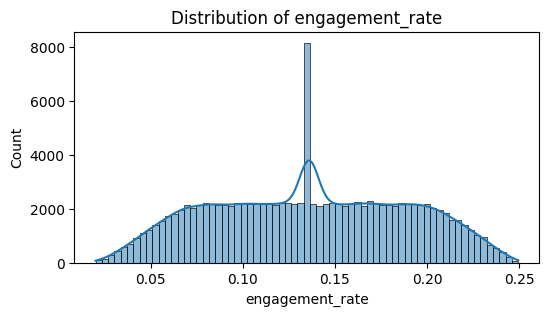

In [63]:
# 3) Histogram for Key Features

cols = ['views', 'watch_time_minutes', 'engagement_rate']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

##BIVARIATE ANALYSIS
To find the relationship with the target (ad_revenue_usd)

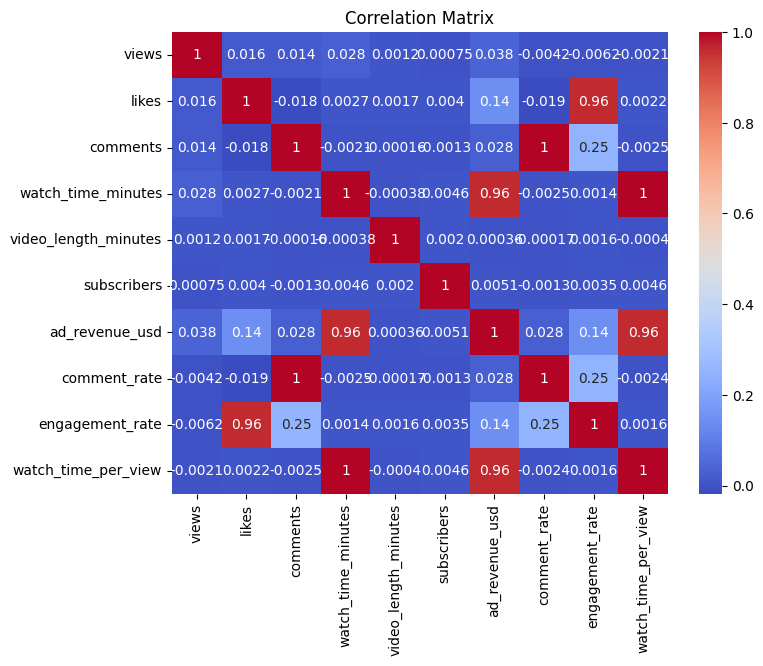

In [64]:
# 1) Correlation Heatmap

corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [65]:
# 2) Correlation with target

df_cleaned.corr(numeric_only=True)['ad_revenue_usd'].sort_values(ascending=False)

,ad_revenue_usd
ad_revenue_usd,1.000000
watch_time_minutes,0.964087
watch_time_per_view,0.963276
engagement_rate,0.144077
likes,0.141937
views,0.037942
comments,0.028335
comment_rate,0.027648
subscribers,0.005065
video_length_minutes,0.000364


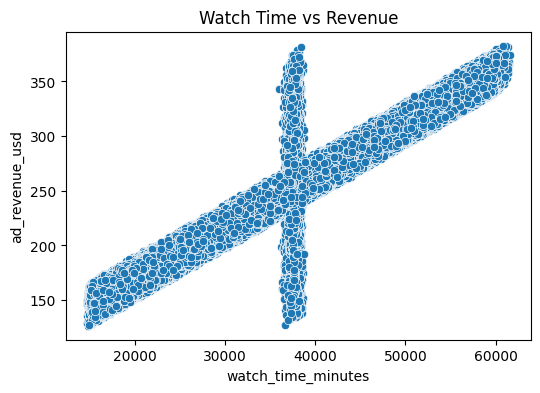

In [66]:
# 3) Scatter Plots

# A) Watch time vs Revenue

plt.figure(figsize=(6,4))
sns.scatterplot(x='watch_time_minutes', y='ad_revenue_usd', data=df_cleaned)
plt.title('Watch Time vs Revenue')
plt.show()

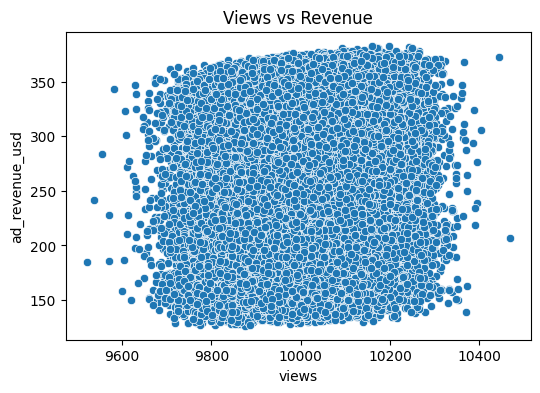

In [67]:
# B) Watch time vs Revenue

plt.figure(figsize=(6,4))
sns.scatterplot(x='views', y='ad_revenue_usd', data=df_cleaned)
plt.title('Views vs Revenue')
plt.show()

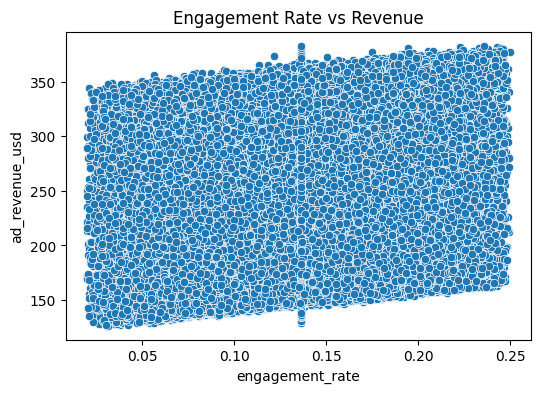

In [68]:
# C) Engagement vs Revenue

plt.figure(figsize=(6,4))
sns.scatterplot(x='engagement_rate', y='ad_revenue_usd', data=df_cleaned)
plt.title('Engagement Rate vs Revenue')
plt.show()

##CATEGORICAL vs NUMERICAL

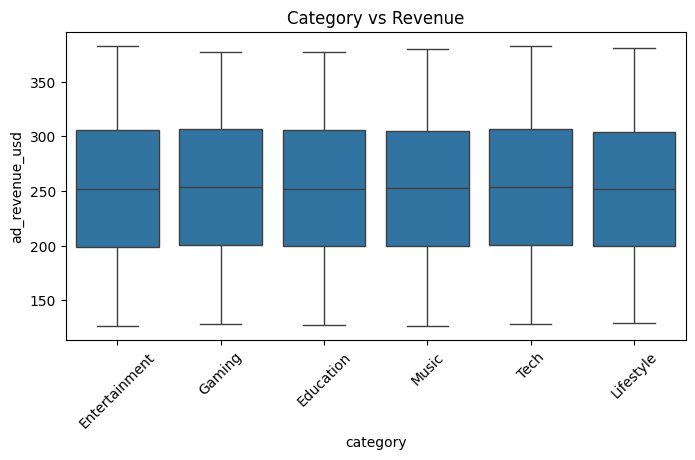

In [69]:
plt.figure(figsize=(8,4))
sns.boxplot(x='category', y='ad_revenue_usd', data=df_cleaned)
plt.xticks(rotation=45)
plt.title('Category vs Revenue')
plt.show()